<a href="https://colab.research.google.com/github/sabrynkhatr696-design/Student-Performance-Prediction/blob/main/student_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Project Overview###
**This project builds a Convolutional Neural Network (CNN) model to classify geometric shapes from images.
The goal is to demonstrate a complete Deep Learning workflow including data preprocessing,
model building, training, evaluation, and performance analysis.**
##Dataset##
https://www.kaggle.com/datasets/reevald/geometric-shapes-mathematics/data

In [ ]:
import tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import imghdr
import cv2
#data processing تنظيف وتحضير بيانات الصور قبل المعالجة"
# المجلد الرئيسي للبيانات
data_dir = '/content/drive/MyDrive/DL/Data'

# الامتدادات المسموح بها
ext = ['jpeg', 'jpg', 'bmp', 'png']

# المرور على الفئات (المجلدات الفرعية )
for image_class in os.listdir(data_dir):
    class_path = os.path.join(data_dir, image_class)

    # تأكد أن المسار مجلد وليس ملف
    if os.path.isdir(class_path):
        # المرور على الصور داخل كل فئة
        for image in os.listdir(class_path):
            image_path = os.path.join(class_path, image)

            # التحقق من امتداد الصورة
            image_ext = imghdr.what(image_path)
            if image_ext not in ext:
                os.remove(image_path)  # حذف الصورة غير الصالحة
                continue  # انتقل للصورة التالية

            # التحقق من إمكانية قراءة الصورة
            img = cv2.imread(image_path)
            if img is None:
                os.remove(image_path)  # حذف الصورة إذا لم تُقرأ

/tmp/ipykernel_217/1334527983.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# تحميل الصور مباشرة من المجلدات المصنفة
data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(128,128),   # إعادة تحجيم الصور
    batch_size=32,          # حجم الدفعة
    class_names=['triangle','trapezoid','square','rhombus','rectangle','parallelogram','kite','circle']
)

# عرض أسماء الفئات للتأكد
print(data.class_names)

Found 12009 files belonging to 8 classes.
['triangle', 'trapezoid', 'square', 'rhombus', 'rectangle', 'parallelogram', 'kite', 'circle']


In [ ]:
#تحويل بيانات الصور إلى دفعات NumPy جاهزة للفحص أو العرض
data_batchs = data.as_numpy_iterator()

In [ ]:
batch = data_batchs.next()

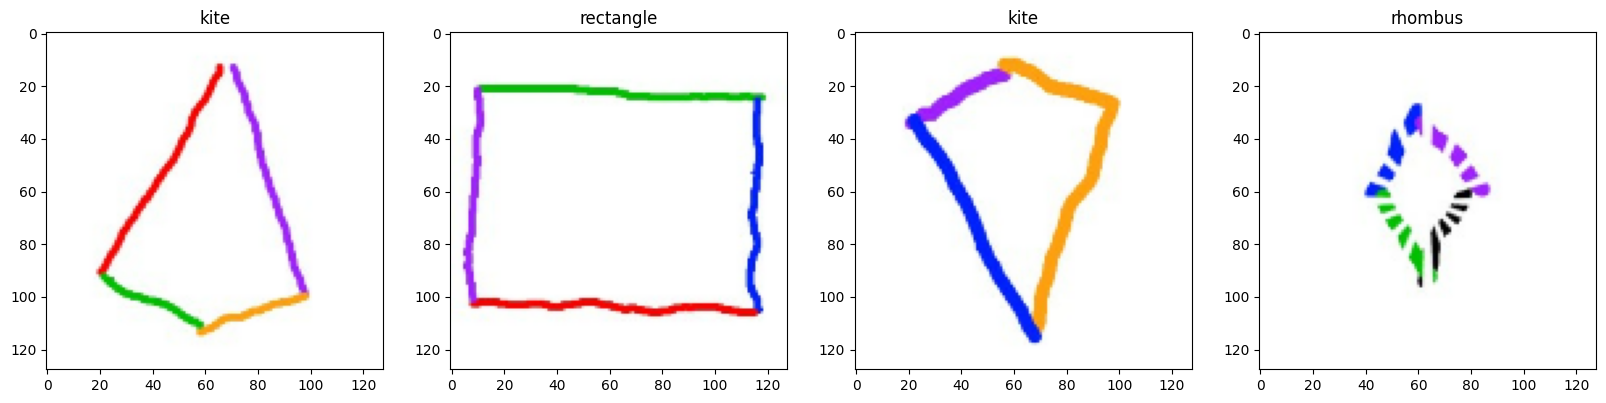

In [ ]:
class_names = data.class_names

fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype("uint8"))  # تحويل الصورة لصيغة صحيحة للعرض
    ax[idx].title.set_text(class_names[batch[1][idx]])  # عرض اسم الفئة بدل الرقم
    # رح يعرض أول 4 صور من الدفعة.
#كل صورة رح يكون عنوانها اسم الفئة (مثلاً: "triangle", "circle"...) بدل رقم التصنيف


In [ ]:
#data normalization تطبيع البيانات بتحويل القيم إلى نطاق [0,1]
data = data.map(lambda x,y: (x/255, y))

In [ ]:
data.as_numpy_iterator().next()

(array([[[[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]],
 
         [[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]],
 
         [[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]],
 
         ...,
 
         [[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]],
 
         [[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]],
 
         [[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]]],
 
 
        [

In [ ]:
int(len(data)*0.70)
#- len(data) → يعطيك طول الـ dataset (عدد العينات).

263

In [ ]:
#data split يقسم البيانات إلى ثلاث مجموعات
train_size = int(len(data)*0.70) #التدريب من البيانات سبعين بالمية
test_size = int(len(data)*0.10) #الاختبار 10بالمية
val_size = int(len(data)*0.20) #التحقق Validation)

In [ ]:
train = data.take(train_size) #- يأخذ أول train_size عنصر من البيانات.
val = data.skip(train_size).take(val_size) #- يتجاوز (skip) عناصر التدريب، ثم يأخذ val_size عنصر للتحقق
test = data.skip(train_size + val_size).take(test_size) #- يتجاوز عناصر التدريب + التحقق، ثم يأخذ test_size عنصر للاختبار

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))

# Output layer for 8 classes
model.add(Dense(8, activation='softmax'))

# Compile
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary() # ملخص هيكل النموذج
#- يساعدك تتأكد أن الطبقات مرتبة صح.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,352 (28.20 MB)

 Trainable params: 7,393,352 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
logdir = '/content/drive/MyDrive/DL/logs/geometric_shapes'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [ ]:
# from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
# import datetime

# # 1- إعداد EarlyStopping
# early_stop = EarlyStopping(
#     monitor='val_loss',       # نراقب الخسارة على بيانات التحقق
#     patience=3,               # إذا ما تحسن الأداء خلال 3 epochs متتالية يوقف
#     restore_best_weights=True # يرجع أفضل وزن للنموذج
# )

# # 2- إعداد TensorBoard
# log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
# tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# # 3- تدريب النموذج مع الاثنين معًا
# history = model.fit(
#     train,
#     validation_data=val,
#     epochs=20,
#     callbacks=[early_stop, tensorboard_callback]
)

In [ ]:
# from tensorflow.keras.callbacks import EarlyStopping

# early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# history = model.fit(train, validation_data=val, epochs=20, callbacks=[early_stop])

In [ ]:
#تدريب النموذج مع بيانات التدريب والتحقق باستخدام TensorBoard
history = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 344s 1s/step - accuracy: 0.5739 - loss: 1.2535 - val_accuracy: 0.9362 - val_loss: 0.2147
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 354s 1s/step - accuracy: 0.9393 - loss: 0.1991 - val_accuracy: 0.9671 - val_loss: 0.1052
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 346s 1s/step - accuracy: 0.9675 - loss: 0.0924 - val_accuracy: 0.9500 - val_loss: 0.1830
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 358s 1s/step - accuracy: 0.9806 - loss: 0.0692 - val_accuracy: 0.9671 - val_loss: 0.1244
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 350s 1s/step - accuracy: 0.9861 - loss: 0.0474 - val_accuracy: 0.9683 - val_loss: 0.1312
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 342s 1s/step - accuracy: 0.9911 - loss: 0.0335 - val_accuracy: 0.9604 - val_loss: 0.1520
Epoch 7/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 352s 1s/step - accuracy: 0.9930 - loss: 0.0237 - val_accuracy: 0.9667 - val_loss: 0.1158
Epoch 8/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 346s 1s/step - accuracy: 0.9943 - loss: 0.0197 - val_accu

In [ ]:
import numpy as np
from tensorflow.keras.metrics import Precision, Recall, SparseCategoricalAccuracy

# تعريف المقاييس
pre = Precision()
re = Recall()
acc = SparseCategoricalAccuracy()

# حلقة على بيانات الاختبار:
for batch in test.as_numpy_iterator():
    x, y = batch
    yhat = model.predict(x)

    # y عبارة عن أرقام الفئات (0–7)
    y_classes = y
    yhat_classes = np.argmax(yhat, axis=1)

    # تحديث المقاييس
    pre.update_state(y_classes, yhat_classes)
    re.update_state(y_classes, yhat_classes)
    acc.update_state(y, yhat)  # هنا acc يقبل y كأرقام والفئات المتوقعة كاحتمالات

# عرض النتائج
print("Precision:", pre.result().numpy())
print("Recall:", re.result().numpy())
print("Accuracy:", acc.result().numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

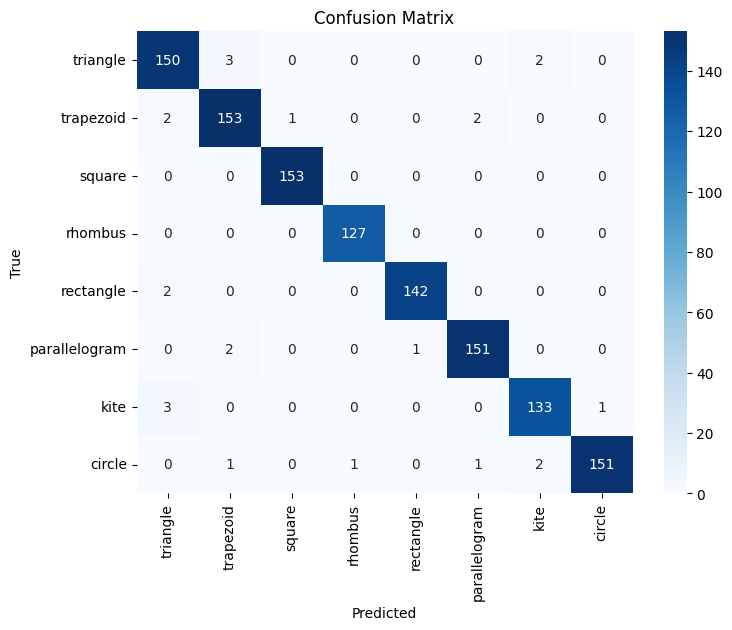

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# جمع كل التوقعات والـ Labels من test
y_true = []
y_pred = []

for batch in test.as_numpy_iterator():
    x, y = batch
    yhat = model.predict(x)
    y_classes = y
    yhat_classes = np.argmax(yhat, axis=1)

    y_true.extend(y_classes)
    y_pred.extend(yhat_classes)

# بناء Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_names = ['triangle','trapezoid','square','rhombus','rectangle','parallelogram','kite','circle']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#رسم منحنى الخسارة باستخدام Matplotlib
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('train loss vs val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [ ]:
#منحنى الدقة (accuracy)

fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('train accuracy vs val accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [ ]:
model.save('shapes_classification.h5')

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model

# 1. حفظ النموذج بعد التدريب
model.save('shapes_classification.h5')

# 2. تحميل النموذج لاحقًا
model = load_model('shapes_classification.h5')

# 3. تجهيز صورة أو دفعة صور للتوقع
# مثلاً: x عبارة عن صورة واحدة أو batch من الصور بحجم (256,256,3) بعد التطبيع
# إذا صورة واحدة لازم تضيف بعد إضافي:
# x = np.expand_dims(normalized_img, axis=0)

# 4. التوقع
yhat = model.predict(x)

# 5. استخراج الفئة المتوقعة
predicted_class = np.argmax(yhat, axis=1)

# 6. عرض اسم الفئة بدل الرقم
class_names = ['triangle','trapezoid','square','rhombus','rectangle','parallelogram','kite','circle']
print("Predicted class:", class_names[predicted_class[0]])

In [ ]:
import numpy as np

yhat = model.predict(x)   # x صورة أو دفعة صور
predicted_class = np.argmax(yhat, axis=1)  # يعطي رقم الفئة
print(predicted_class)

In [ ]:
class_names = ['triangle','trapezoid','square','rhombus','rectangle','parallelogram','kite','circle']
print("Predicted class:", class_names[predicted_class[0]])